In [1]:
import numpy as np

import gropt
from gropt.diffusion import DiffParams, solve, te_search, SolverCfg
from gropt.plot import plot_diff

gropt.setup_logging(9)

  TE=122.00 ms (N=531) -> b=   442.5 conv=True  infeasible
  TE=202.00 ms (N=931) -> b=  2543.1 conv=False infeasible
  TE=361.80 ms (N=1730) -> b= 17078.4 conv=True  feasible
  TE= 42.00 ms (N=131) -> b=     0.7 conv=True  infeasible
  TE=201.80 ms (N=930) -> b=  2674.0 conv=True  feasible
  TE=121.80 ms (N=530) -> b=   442.6 conv=False infeasible
  TE=161.80 ms (N=730) -> b=  1228.5 conv=True  feasible
  TE=142.00 ms (N=631) -> b=   766.9 conv=True  infeasible
  TE=151.80 ms (N=680) -> b=   975.3 conv=False infeasible
  TE=156.80 ms (N=705) -> b=  1096.4 conv=True  feasible
  TE=154.40 ms (N=693) -> b=  1037.3 conv=True  feasible
  TE=153.20 ms (N=687) -> b=  1008.6 conv=True  feasible
  TE=152.60 ms (N=684) -> b=   996.6 conv=True  infeasible
  TE=152.80 ms (N=685) -> b=   998.9 conv=True  infeasible
  TE=153.00 ms (N=686) -> b=  1006.0 conv=True  feasible


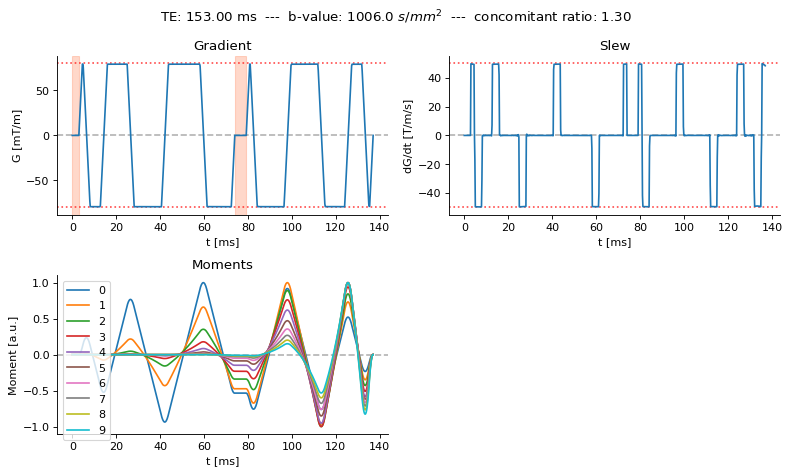

Search time: 1136.03 ms


In [10]:
# Problem definition
cfg = DiffParams(
    TE=50e-3,
    T_90=3e-3,
    T_180=5e-3,
    T_readout=16e-3,
    dt=200e-6,
    gmax=0.08,
    smax=50.0,
    MMT=9,
)

res = te_search(cfg, target_b=1000, mode="obj", verbose=True)
plot_diff(res['cfg'], res['result'])

print(f'Search time: {1000*res["search_time"]:.2f} ms')

  TE=122.00 ms (N=266) -> b= 46239.6 conv=True  feasible
  TE= 42.00 ms (N=66) -> b=   187.5 conv=True  infeasible
  TE= 82.00 ms (N=166) -> b=  9196.7 conv=True  feasible
  TE= 61.60 ms (N=115) -> b=  2602.2 conv=True  feasible
  TE= 52.00 ms (N=91) -> b=  1202.7 conv=True  feasible
  TE= 46.80 ms (N=78) -> b=   655.2 conv=True  infeasible
  TE= 49.20 ms (N=84) -> b=   913.8 conv=True  infeasible
  TE= 50.40 ms (N=87) -> b=  1043.8 conv=True  feasible
  TE= 50.00 ms (N=86) -> b=   982.9 conv=True  infeasible


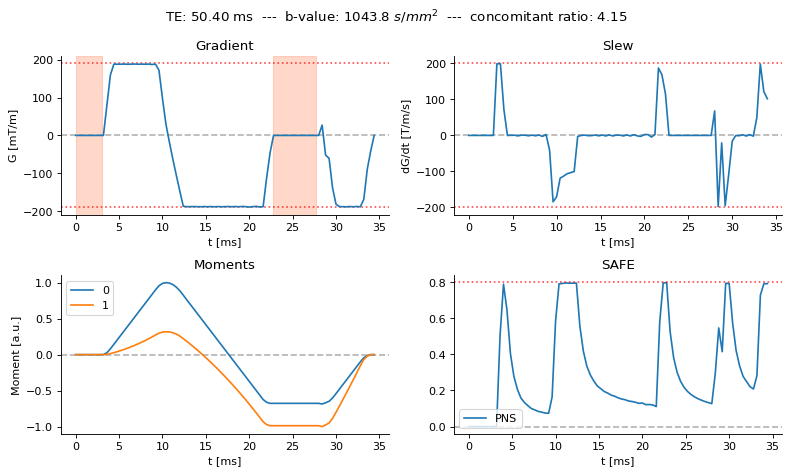

Search time: 283.89 ms


In [9]:
# Problem definition
cfg = DiffParams(
    TE=50e-3,
    T_90=3e-3,
    T_180=5e-3,
    T_readout=16e-3,
    dt=400e-6,
    gmax=0.19,
    smax=200.0,
    pns_lim = 0.8,
    # cns_lim = 0.8,
    MMT=1,
)

res = te_search(cfg, target_b=1000, mode="obj", verbose=True)
plot_diff(res['cfg'], res['result'])

print(f'Search time: {1000*res["search_time"]:.2f} ms')

In [ ]:
# Problem definition
cfg = DiffParams(
    TE=50e-3,
    T_90=3e-3,
    T_180=5e-3,
    T_readout=16e-3,
    dt=400e-6,
    gmax=0.19,
    smax=200.0,
    MMT=2,
    pns_lim = 0.9,
)

res = te_search(cfg, target_b=1000, mode="obj", verbose=False)
plot_diff(res['cfg'], res['result'])

print(f'Search time: {1000*res["search_time"]:.2f} ms')

In [ ]:
print(res.keys())

In [ ]:
# TE sweep — the TE-search precursor
res = sweep(cfg, cfg_grid={"TE": np.linspace(50e-3, 90e-3, 9)}, parallel=False)
for r in sorted(res, key=lambda r: r["cfg"].TE):
    print(f"TE={r['cfg'].TE*1e3:.0f}ms  b={r['bvalue']:.0f}  conv={r['converged']}")